# **环境搭建与验证**

In [ ]:
pip install torch==2.5.1 torchvision==0.20.1 --extra-index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 88.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 113.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 62.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 151.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 19.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 42.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
# 安装必要库
!pip install scipy opencv-python ultralytics==8.2.0
!pip install PyQt5

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
data_path = '/content/drive/MyDrive/Colab Notebooks/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.chdir('/content/stanford_cars')

In [ ]:
import scipy.io as sio
import yaml
import numpy as np

# 加载 .mat 文件
mat_data = sio.loadmat('stanford_cars/devkit/cars_meta.mat')  # 替换为实际文件名
class_names_raw = mat_data['class_names']

# 提取类别名称（确保为普通字符串）
class_names = [str(name[0]) for name in class_names_raw.flatten()]

# 构建 data.yaml 内容
data_dict = {
    'path': '/content/stanford_cars',
    'train': 'images/train',
    'val': 'images/val',
    'nc': len(class_names),
    'names': class_names
}

# 写入文件，注意编码和 allow_unicode
with open('data.yaml', 'w', encoding='utf-8') as f:
    yaml.dump(data_dict, f,
              default_flow_style=False,
              allow_unicode=True,
              sort_keys=False)
print("data.yaml 已生成，共 {} 个类别".format(len(class_names)))

data.yaml 已生成，共 196 个类别


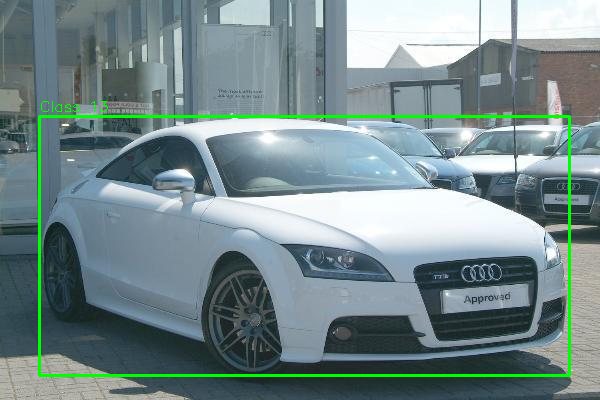

In [ ]:
from detect_tools import draw_yolo_data
# 或者使用 OpenCV 简单验证
import cv2
import os

# 选取一张训练集图片
img_path = 'images/train/00001.jpg'
label_path = 'labels/train/00001.txt'

img = cv2.imread(img_path)
h, w = img.shape[:2]

with open(label_path, 'r') as f:
    data = f.readline().strip().split()
    class_id, xc, yc, bw, bh = map(float, data)
    x1 = int((xc - bw/2) * w)
    y1 = int((yc - bh/2) * h)
    x2 = int((xc + bw/2) * w)
    y2 = int((yc + bh/2) * h)
    cv2.rectangle(img, (x1, y1), (x2, y2), (0,255,0), 2)
    cv2.putText(img, f"Class {int(class_id)}", (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)

# 显示（Colab 中可使用 cv2_imshow）
from google.colab.patches import cv2_imshow
cv2_imshow(img)

# **训练流程**



In [ ]:
from ultralytics import YOLO

model = YOLO("/content/yolov8n.pt")
model.train(
    data="data.yaml",
    epochs=5,
    imgsz=640,
    batch=16,
    project="stanford_cars",   # W&B 项目名
    name="train",              # 实验名称
    save_dir="/content/stanford_cars/train_results"  # 保存路径
)


New https://pypi.org/project/ultralytics/8.4.24 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.0 🚀 Python-3.12.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: task=detect, mode=train, model=/content/yolov8n.pt, data=data.yaml, epochs=5, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=stanford_cars, name=train2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_f

/usr/local/lib/python3.12/dist-packages/ultralytics/nn/tasks.py:732: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(file, map_location="cpu")


Model summary: 225 layers, 3375228 parameters, 3375212 gradients, 9.9 GFLOPs

Transferred 319/355 items from pretrained weights
TensorBoard: Start with 'tensorboard --logdir stanford_cars/train2', view at http://localhost:6006/
Freezing layer 'model.22.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks with YOLOv8n...


100%|██████████| 6.23M/6.23M [00:00<00:00, 125MB/s]
/usr/local/lib/python3.12/dist-packages/ultralytics/nn/tasks.py:732: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt =

AMP: checks passed ✅


...

                   all       8041       8041    0.00638      0.943     0.0206     0.0191

5 epochs completed in 0.149 hours.
Optimizer stripped from stanford_cars/train2/weights/last.pt, 7.0MB
Optimizer stripped from stanford_cars/train2/weights/best.pt, 7.0MB

Validating stanford_cars/train2/weights/best.pt...
Ultralytics YOLOv8.2.0 🚀 Python-3.12.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA L4, 22563MiB)
Model summary (fused): 168 layers, 3369812 parameters, 0 gradients, 9.8 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 252/252 [00:31<00:00,  7.92it/s]


                   all       8041       8041    0.00638      0.943     0.0206      0.019
AM General Hummer SUV 2000       8041         44    0.00572          1     0.0176     0.0149
   Acura RL Sedan 2012       8041         32    0.00608          1     0.0093    0.00918
   Acura TL Sedan 2012       8041         43    0.00592          1     0.0113    0.00978
  Acura TL Type-S 2008       8041         42    0.00659          1     0.0206     0.0205
  Acura TSX Sedan 2012       8041         40    0.00645          1      0.011     0.0105
Acura Integra Type R 2001       8041         44    0.00767      0.909     0.0128     0.0123
Acura ZDX Hatchback 2012       8041         39    0.00543          1     0.0108     0.0106
Aston Martin V8 Vantage Convertible 2012       8041         45    0.00671          1     0.0541     0.0507
Aston Martin V8 Vantage Coupe 2012       8041         41    0.00712          1     0.0348     0.0305
Aston Martin Virage Convertible 2012       8041         33    0.00535  

lr/pg0,▃▇█▅▁
lr/pg1,▃▇█▅▁
lr/pg2,▃▇█▅▁
metrics/mAP50(B),▁▃▅▇█
metrics/mAP50-95(B),▁▃▅▇█
metrics/precision(B),▁▇▇▇█
metrics/recall(B),▁▅▇██
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
+6,...


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,  53,  54,  55,  56,  57,  58,  59,  60,  61,
        62,  63,  64,  65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123,
       124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 1

In [ ]:
%cd /content
!zip -r /content/stanford_cars.zip /content/stanford_cars

流式输出内容被截断，只能显示最后 5000 行内容。
  adding: content/stanford_cars/images/train/07257.jpg (deflated 0%)
  adding: content/stanford_cars/images/train/06178.jpg (deflated 5%)
  adding: content/stanford_cars/images/train/06867.jpg (deflated 0%)
  adding: content/stanford_cars/images/train/03712.jpg (deflated 8%)
  adding: content/stanford_cars/images/train/03220.jpg (deflated 0%)
  adding: content/stanford_cars/images/train/06941.jpg (deflated 1%)
  adding: content/stanford_cars/images/train/04836.jpg (deflated 1%)
  adding: content/stanford_cars/images/train/01669.jpg (deflated 0%)
  adding: content/stanford_cars/images/train/07163.jpg (deflated 3%)
  adding: content/stanford_cars/images/train/06494.jpg (deflated 0%)
  adding: content/stanford_cars/images/train/03681.jpg (deflated 0%)
  adding: content/stanford_cars/images/train/02769.jpg (deflated 2%)
  adding: content/stanford_cars/images/train/03721.jpg (deflated 1%)
  adding: content/stanford_cars/images/train/07048.jpg (deflated 1%)
  addin

In [ ]:
!ls -lh /content


total 1.9G
drwx------  5 root root 4.0K Mar 22 15:14 drive
drwxr-xr-x  1 root root 4.0K Feb  6 14:31 sample_data
drwx------ 11 root root 4.0K Mar 22 16:31 stanford_cars
-rw-r--r--  1 root root 1.9G Mar 22 16:36 stanford_cars.zip
